# Bond Futures Roll — Internalization Engine
### Sep26 → Dec26 quarterly roll, netted across desks

**Problem.** Every quarter each desk holding a position in the expiring contract (Sep26) has to roll it
into the new front contract (Dec26):

- **LONG** desk → **SELL Sep26 / BUY Dec26**
- **SHORT** desk → **BUY Sep26 / SELL Dec26**

Done independently, every desk pays the bid/offer spread (and impact) on *both* legs. But one desk's
"sell Sep26" and another desk's "buy Sep26" can be crossed **internally** at a fair price instead —
zero spread cost, zero market footprint, and the offsetting Dec26 legs cross the same way, in the
opposite direction, against the same two desks.

**This notebook:**
1. Splits desks into long-rollers / short-rollers
2. Crosses them internally, largest clip first, via a cumulative-volume waterfall
3. Produces a full two-leg blotter — *which desk buys/sells which contract, from/to whom*
4. Sends only the unavoidable net imbalance to the market, as one Sep26/Dec26 calendar spread
5. Prices out the execution cost saved, with summary statistics and a dashboard PNG

**Why this minimizes execution PnL leakage.** The residual sent to market can never be smaller than
`|Σlongs − Σshorts|` across all desks — that net imbalance has to trade somewhere no matter how it's
netted. The crossing engine hits that floor exactly, so the market footprint (and the spread/impact
cost paid on it) is already at its **mathematical minimum**, not a heuristic approximation. The
largest-clip-first matching order doesn't shrink the residual further — it only minimizes the number
of internal tickets to book.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dataclasses import dataclass

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.edgecolor": "#444444",
    "axes.labelcolor": "#222222",
    "text.color": "#222222",
    "xtick.color": "#444444",
    "ytick.color": "#444444",
    "axes.grid": True,
    "grid.color": "#E5E5E5",
    "grid.linewidth": 0.6,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})
NAVY, TEAL, GOLD, RED, GREY = "#1F3864", "#2E7D8C", "#C9A227", "#B5474D", "#8C8C8C"
pd.set_option("display.width", 120)

## 1. Desk positions & cost assumptions

Replace `desks` with the real end-of-day Sep26 blotter (signed contracts: long +, short −), and tune
`RollCostParams` to the real product's tick value and observed spread/impact.

In [2]:
desks = pd.DataFrame([
    {"desk": "Rates Options A", "position": 1200},
    {"desk": "Rates Options B", "position": -800},
    {"desk": "STIR Desk", "position": 450},
    {"desk": "Swaps Desk", "position": -600},
    {"desk": "Macro Fund Desk", "position": 300},
    {"desk": "Basis Trading", "position": -250},
    {"desk": "Relative Value", "position": 150},
])


@dataclass
class RollCostParams:
    tick_value: float = 15.625          # $ per tick (10Y UST future, 1/64)
    half_spread_ticks: float = 0.5      # half the bid/offer spread, in ticks
    impact_ticks: float = 0.25          # extra slippage/impact per contract, in ticks
    internal_crossing_fee: float = 0.0  # $ per contract booking/compliance cost for an internal cross


params = RollCostParams()
desks

,desk,position
0,Rates Options A,1200
1,Rates Options B,-800
2,STIR Desk,450
3,Swaps Desk,-600
4,Macro Fund Desk,300
5,Basis Trading,-250
6,Relative Value,150


## 2. Netting engine

`net_roll_positions` splits desks into sellers (long-rollers) and buyers (short-rollers), sorts each
queue largest-first, and matches them via a two-pointer sweep — the same cumulative-interval logic
used for tranche waterfalls. Whatever is left over after the sweep is the unavoidable net imbalance.

In [3]:
def net_roll_positions(desks: pd.DataFrame) -> dict:
    """
    Cross long-rollers (sell Sep26 / buy Dec26) against short-rollers
    (buy Sep26 / sell Dec26), largest clip first. What can't be crossed
    is the net imbalance -- provably the smallest possible ticket to
    send to the market (it equals |sum(longs) - sum(shorts)|, a floor
    no netting order can improve on), so this minimizes market
    execution / PnL leakage by construction, not by approximation.
    """
    sellers, buyers = [], []
    for _, row in desks.iterrows():
        desk, pos = row["desk"], row["position"]
        if pos > 0:
            sellers.append([desk, float(pos)])
        elif pos < 0:
            buyers.append([desk, float(-pos)])

    sellers.sort(key=lambda x: -x[1])
    buyers.sort(key=lambda x: -x[1])

    crosses = []
    i = j = 0
    cross_id = 1
    while i < len(sellers) and j < len(buyers):
        s_desk, s_qty = sellers[i]
        b_desk, b_qty = buyers[j]
        matched = min(s_qty, b_qty)
        if matched > 0:
            crosses.append({
                "cross_id": cross_id,
                "seller_desk": s_desk,   # sells Sep26 / buys Dec26
                "buyer_desk": b_desk,    # buys Sep26 / sells Dec26
                "qty": matched,
            })
            cross_id += 1
        sellers[i][1] -= matched
        buyers[j][1] -= matched
        if sellers[i][1] <= 1e-9:
            i += 1
        if buyers[j][1] <= 1e-9:
            j += 1

    residual_sell = sum(q for _, q in sellers[i:])
    residual_buy = sum(q for _, q in buyers[j:])

    market_orders = []
    if residual_sell > 1e-9:
        market_orders.append({"action": "SELL Sep26 / BUY Dec26 (net roll spread)",
                               "qty": residual_sell,
                               "note": "Net long imbalance -> executed as one calendar spread order"})
    if residual_buy > 1e-9:
        market_orders.append({"action": "BUY Sep26 / SELL Dec26 (net roll spread)",
                               "qty": residual_buy,
                               "note": "Net short imbalance -> executed as one calendar spread order"})

    gross_longs = desks.loc[desks.position > 0, "position"].sum()
    gross_shorts = -desks.loc[desks.position < 0, "position"].sum()
    internal_matched = sum(c["qty"] for c in crosses)
    market_residual = residual_sell + residual_buy

    stats = {
        "gross_long_contracts": gross_longs,
        "gross_short_contracts": gross_shorts,
        "internal_matched_contracts": internal_matched,
        "market_residual_contracts": market_residual,
        "leg_executions_no_netting": 2 * (gross_longs + gross_shorts),
        "leg_executions_with_netting": 2 * market_residual,
        "leg_executions_internalized": 2 * (gross_longs + gross_shorts) - 2 * market_residual,
        "num_internal_tickets": len(crosses),
    }
    return {"crosses": crosses, "market_orders": market_orders, "stats": stats}


result = net_roll_positions(desks)
crosses, market_orders, stats = result["crosses"], result["market_orders"], result["stats"]
stats

{'gross_long_contracts': np.int64(2100),
 'gross_short_contracts': np.int64(1650),
 'internal_matched_contracts': 1650.0,
 'market_residual_contracts': 450.0,
 'leg_executions_no_netting': np.int64(7500),
 'leg_executions_with_netting': 900.0,
 'leg_executions_internalized': np.float64(6600.0),
 'num_internal_tickets': 4}

## 3. Full two-leg blotter

*Who buys from whom, on both contracts.* Each internal cross generates one **Sep26** ticket (the
long-roller sells to the short-roller) and the offsetting **Dec26** ticket in the opposite direction
(the short-roller sells Dec26 back to the long-roller) — that's the "buy the next contract" leg of the
roll, crossed internally against the very same counterparty.

In [4]:
def build_blotter(crosses: list) -> pd.DataFrame:
    rows = []
    for c in crosses:
        rows.append({"cross_id": c["cross_id"], "leg": "Sep26", "action": "SELL",
                      "desk_sells": c["seller_desk"], "desk_buys": c["buyer_desk"], "qty": c["qty"]})
        rows.append({"cross_id": c["cross_id"], "leg": "Dec26", "action": "SELL",
                      "desk_sells": c["buyer_desk"], "desk_buys": c["seller_desk"], "qty": c["qty"]})
    return pd.DataFrame(rows)


blotter = build_blotter(crosses)
blotter

,cross_id,leg,action,desk_sells,desk_buys,qty
0,1,Sep26,SELL,Rates Options A,Rates Options B,800.0
1,1,Dec26,SELL,Rates Options B,Rates Options A,800.0
2,2,Sep26,SELL,Rates Options A,Swaps Desk,400.0
3,2,Dec26,SELL,Swaps Desk,Rates Options A,400.0
4,3,Sep26,SELL,STIR Desk,Swaps Desk,200.0
5,3,Dec26,SELL,Swaps Desk,STIR Desk,200.0
6,4,Sep26,SELL,STIR Desk,Basis Trading,250.0
7,4,Dec26,SELL,Basis Trading,STIR Desk,250.0


## 4. Desk-level summary — how much of each desk's roll was internalized vs. left for the market

In [5]:
def desk_summary(desks: pd.DataFrame, crosses: list) -> pd.DataFrame:
    matched_by_desk = {}
    for c in crosses:
        matched_by_desk[c["seller_desk"]] = matched_by_desk.get(c["seller_desk"], 0) + c["qty"]
        matched_by_desk[c["buyer_desk"]] = matched_by_desk.get(c["buyer_desk"], 0) + c["qty"]

    out = desks.copy()
    out["roll_type"] = np.where(out.position > 0, "LONG", np.where(out.position < 0, "SHORT", "FLAT"))
    out["roll_qty"] = out.position.abs()
    out["internally_matched"] = out.desk.map(matched_by_desk).fillna(0)
    out["market_residual"] = out.roll_qty - out.internally_matched
    out["pct_internalized"] = np.where(out.roll_qty > 0, out.internally_matched / out.roll_qty, np.nan)
    return out.sort_values("roll_qty", ascending=False).reset_index(drop=True)


summary = desk_summary(desks, crosses)
summary

,desk,position,roll_type,roll_qty,internally_matched,market_residual,pct_internalized
0,Rates Options A,1200,LONG,1200,1200.0,0.0,1.0
1,Rates Options B,-800,SHORT,800,800.0,0.0,1.0
2,Swaps Desk,-600,SHORT,600,600.0,0.0,1.0
3,STIR Desk,450,LONG,450,450.0,0.0,1.0
4,Macro Fund Desk,300,LONG,300,0.0,300.0,0.0
5,Basis Trading,-250,SHORT,250,250.0,0.0,1.0
6,Relative Value,150,LONG,150,0.0,150.0,0.0


## 5. Residual market order(s)

The only tickets that touch the market — sized to the provable minimum.

In [6]:
for m in market_orders:
    print(f"{m['action']}: {m['qty']:,.0f} lots  ({m['note']})")
pd.DataFrame(market_orders)

SELL Sep26 / BUY Dec26 (net roll spread): 450 lots  (Net long imbalance -> executed as one calendar spread order)


,action,qty,note
0,SELL Sep26 / BUY Dec26 (net roll spread),450.0,Net long imbalance -> executed as one calendar...


## 6. Execution cost savings

In [7]:
def cost_savings(stats: dict, params: RollCostParams) -> dict:
    cost_per_contract_leg = params.tick_value * (params.half_spread_ticks + params.impact_ticks)
    gross_cost = stats["leg_executions_no_netting"] * cost_per_contract_leg
    net_market_cost = stats["leg_executions_with_netting"] * cost_per_contract_leg
    internal_admin_cost = stats["leg_executions_internalized"] * params.internal_crossing_fee
    gross_savings = gross_cost - net_market_cost
    net_savings = gross_savings - internal_admin_cost
    return {
        "cost_per_contract_leg": cost_per_contract_leg,
        "cost_if_no_netting": gross_cost,
        "cost_with_netting": net_market_cost + internal_admin_cost,
        "gross_savings": gross_savings,
        "internal_admin_cost": internal_admin_cost,
        "net_savings": net_savings,
        "savings_pct": (net_savings / gross_cost * 100) if gross_cost else 0.0,
    }


savings = cost_savings(stats, params)
pd.Series(savings).to_frame("value")

,value
cost_per_contract_leg,11.71875
cost_if_no_netting,87890.62500
cost_with_netting,10546.87500
gross_savings,77343.75000
internal_admin_cost,0.00000
net_savings,77343.75000
savings_pct,88.00000


## 7. Statistics

A couple of extra diagnostics worth tracking quarter to quarter: how concentrated the roll volume is
across desks (Herfindahl-Hirschman index — closer to 1/n means more evenly spread), and the average
internal clip size.

In [8]:
concentration = summary.roll_qty / summary.roll_qty.sum()
hhi = float((concentration ** 2).sum())
avg_clip = blotter.loc[blotter.leg == "Sep26", "qty"].mean()

print(f"HHI (desk concentration of roll volume): {hhi:.3f}  (1/n = {1/len(desks):.3f} = perfectly even)")
print(f"Average internal clip size: {avg_clip:,.0f} lots")
print(f"Number of internal tickets: {stats['num_internal_tickets']}")
print(f"Internalization rate: {stats['internal_matched_contracts'] / (stats['gross_long_contracts']+stats['gross_short_contracts']):.1%} of gross volume")
print(f"Execution cost cut: {savings['savings_pct']:.1f}%")

HHI (desk concentration of roll volume): 0.200  (1/n = 0.143 = perfectly even)
Average internal clip size: 412 lots
Number of internal tickets: 4
Internalization rate: 44.0% of gross volume
Execution cost cut: 88.0%


## 8. Dashboard

Six-panel summary saved as a standalone PNG (`roll_dashboard.png`) for circulation on the desk.

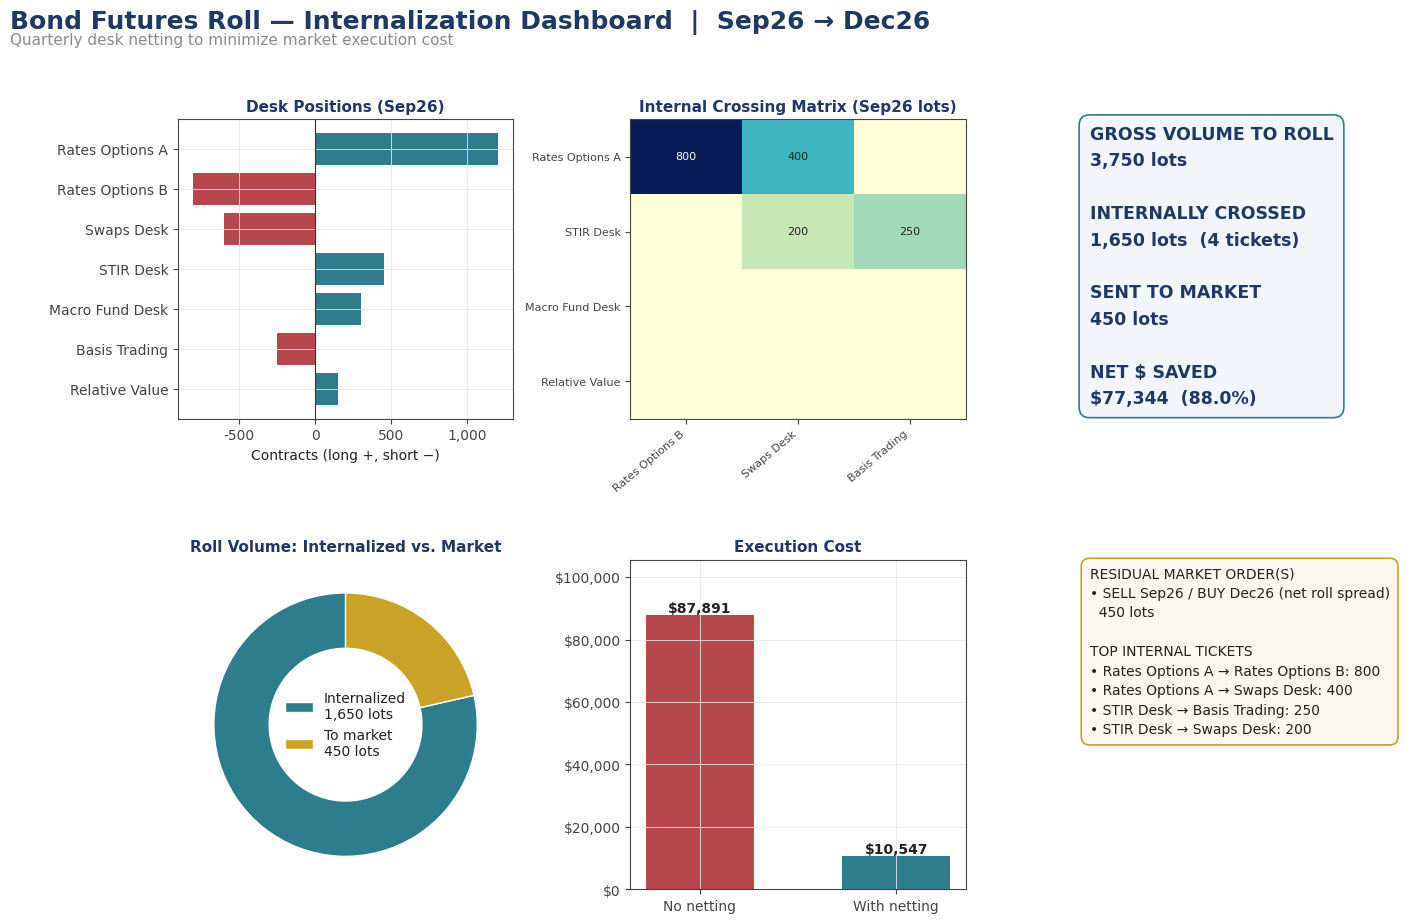

Dashboard saved to roll_dashboard.png


In [9]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.1], hspace=0.45, wspace=0.35)

fig.suptitle("Bond Futures Roll — Internalization Dashboard  |  Sep26 → Dec26",
             fontsize=18, fontweight="bold", color=NAVY, x=0.02, ha="left", y=0.99)
fig.text(0.02, 0.955, "Quarterly desk netting to minimize market execution cost",
          fontsize=11, color=GREY, ha="left")

# --- panel 1: desk positions ---
ax1 = fig.add_subplot(gs[0, 0])
colors = [TEAL if p > 0 else RED for p in summary.position]
ax1.barh(summary.desk[::-1], summary.position[::-1], color=colors[::-1])
ax1.axvline(0, color="#333333", linewidth=0.8)
ax1.set_title("Desk Positions (Sep26)", fontweight="bold", color=NAVY, fontsize=11)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax1.set_xlabel("Contracts (long +, short −)")

# --- panel 2: crossing matrix heatmap ---
ax2 = fig.add_subplot(gs[0, 1])
sellers_names = list(summary.loc[summary.position > 0, "desk"])
buyers_names = list(summary.loc[summary.position < 0, "desk"])
mat = pd.DataFrame(0.0, index=sellers_names, columns=buyers_names)
for c in crosses:
    mat.loc[c["seller_desk"], c["buyer_desk"]] = c["qty"]
im = ax2.imshow(mat.values, cmap="YlGnBu", aspect="auto")
ax2.set_xticks(range(len(buyers_names)))
ax2.set_xticklabels(buyers_names, rotation=40, ha="right", fontsize=8)
ax2.set_yticks(range(len(sellers_names)))
ax2.set_yticklabels(sellers_names, fontsize=8)
for yi in range(mat.shape[0]):
    for xi in range(mat.shape[1]):
        v = mat.values[yi, xi]
        if v > 0:
            ax2.text(xi, yi, f"{v:,.0f}", ha="center", va="center", fontsize=8,
                      color="white" if v > mat.values.max() * 0.5 else "#222222")
ax2.set_title("Internal Crossing Matrix (Sep26 lots)", fontweight="bold", color=NAVY, fontsize=11)
ax2.grid(False)

# --- panel 3: KPI text panel ---
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis("off")
kpi_text = (
    f"GROSS VOLUME TO ROLL\n{stats['gross_long_contracts']+stats['gross_short_contracts']:,.0f} lots\n\n"
    f"INTERNALLY CROSSED\n{stats['internal_matched_contracts']:,.0f} lots  ({stats['num_internal_tickets']} tickets)\n\n"
    f"SENT TO MARKET\n{stats['market_residual_contracts']:,.0f} lots\n\n"
    f"NET $ SAVED\n${savings['net_savings']:,.0f}  ({savings['savings_pct']:.1f}%)"
)
ax3.text(0.02, 0.98, kpi_text, transform=ax3.transAxes, fontsize=12.5, va="top", ha="left",
          linespacing=1.6, color=NAVY, fontweight="bold",
          bbox=dict(boxstyle="round,pad=0.6", facecolor="#F2F6FA", edgecolor=TEAL, linewidth=1.2))

# --- panel 4: internalized vs market volume ---
ax4 = fig.add_subplot(gs[1, 0])
vals = [stats["internal_matched_contracts"], stats["market_residual_contracts"]]
labels = [f"Internalized\n{vals[0]:,.0f} lots", f"To market\n{vals[1]:,.0f} lots"]
wedges, _ = ax4.pie(vals, colors=[TEAL, GOLD], startangle=90,
                     wedgeprops=dict(width=0.42, edgecolor="white"))
ax4.legend(wedges, labels, loc="center", fontsize=10, frameon=False)
ax4.set_title("Roll Volume: Internalized vs. Market", fontweight="bold", color=NAVY, fontsize=11)

# --- panel 5: cost comparison ---
ax5 = fig.add_subplot(gs[1, 1])
bars = ax5.bar(["No netting", "With netting"],
                [savings["cost_if_no_netting"], savings["cost_with_netting"]],
                color=[RED, TEAL], width=0.55)
for b in bars:
    ax5.text(b.get_x() + b.get_width() / 2, b.get_height(), f"${b.get_height():,.0f}",
              ha="center", va="bottom", fontsize=10, fontweight="bold")
ax5.set_title("Execution Cost", fontweight="bold", color=NAVY, fontsize=11)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax5.set_ylim(0, savings["cost_if_no_netting"] * 1.2)

# --- panel 6: market orders + top tickets ---
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
lines = ["RESIDUAL MARKET ORDER(S)"]
for m in market_orders:
    lines.append(f"• {m['action']}\n  {m['qty']:,.0f} lots")
lines.append("")
lines.append("TOP INTERNAL TICKETS")
top = sorted(crosses, key=lambda c: -c["qty"])[:5]
for c in top:
    lines.append(f"• {c['seller_desk']} → {c['buyer_desk']}: {c['qty']:,.0f}")
ax6.text(0.02, 0.98, "\n".join(lines), transform=ax6.transAxes, fontsize=10, va="top", ha="left",
          linespacing=1.5, color="#222222",
          bbox=dict(boxstyle="round,pad=0.6", facecolor="#FBF8EF", edgecolor=GOLD, linewidth=1.2))

fig.savefig("roll_dashboard.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()
print("Dashboard saved to roll_dashboard.png")

## 9. Swap in your real book

To run this on the actual desk blotter: replace the `desks` DataFrame in section 1 with the live Sep26
positions, tune `RollCostParams` to the real product, and re-run all cells (`Kernel → Restart & Run
All`). Everything downstream — blotter, desk summary, market orders, cost savings, statistics, and the
dashboard PNG — recomputes automatically.